# xT 男女足训练数据比较：同一份女足测试集上的差异

这个 notebook 重新实现 `three_method_comparison-2.ipynb` 里的 **Method 2 — position-based xT**，但把原来压缩在一个 cell 里的代码拆成更容易读的小步骤。

核心问题只有一个：

> 用男足数据学出来的 xT，和用女足数据学出来的 xT，当它们被用在同一份女足测试动作上时，给出的球员价值/排名有什么差异？

整体流程：

1. 加载男女足 SPADL actions。
2. 在女足比赛层面切出 held-out test games。
3. 用男足 actions 训练一张 `men_xt_map`。
4. 用女足 train games 训练一张 `women_xt_map`。
5. 把同一批女足 test moves 分别放到两张 xT map 上打分。
6. 按球员汇总，比较 `men_model_xt` 和 `women_model_xt`。

## 0. xT 和 xG 在数据输入上的区别

`xG` 主要看 **Shot events**，因为它回答的是：这脚射门进球概率是多少？

`xT` 不能只看射门。xT 要学习一张“球场位置威胁地图”，所以训练时需要两类动作：

- **Shot actions**：告诉模型哪些位置能直接产生进球威胁。
- **Move actions**：告诉模型球通常会从一个位置移动到哪里。这里主要是 `pass` 和 `dribble` / `carry`。

训练完 xT map 之后，给一个 move 打分时才使用：

```text
xT(move) = xT(end_location) - xT(start_location)
```

所以这个 notebook 里要区分：

- **训练 xT map 时**：看 shots + movement actions。
- **比较男足 xT vs 女足 xT 时**：把两个 xT map 用在同一份女足 movement actions 上。

## 1. Imports 和 constants

原 notebook 默认 SPADL 坐标是 105 × 68。这里把 pitch size、grid size 和 action type 都显式写出来，避免魔法数字散落在代码里。

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np

# Compatibility aliases needed by socceraction/pandera on NumPy 2.x.
if not hasattr(np, 'string_'):
    np.string_ = np.bytes_
if not hasattr(np, 'float_'):
    np.float_ = np.float64
if not hasattr(np, 'complex_'):
    np.complex_ = np.complex128
import pandas as pd
from scipy import stats
from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
OPEN_DATA_DIR = Path("open-data/data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42

PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0

GRID_ROWS = 12   # y direction / pitch width
GRID_COLS = 16   # x direction / pitch length
XT_ITERATIONS = 30
ALIGN_ATTACKING_DIRECTION = True

SHOT_ACTION_TYPE = "shot"
MOVE_ACTION_TYPES = ["pass", "dribble"]
SUCCESS_RESULT = "success"

MIN_ACTIONS_PER_PLAYER = 100

if OPEN_DATA_DIR.exists():
    statsbomb_loader = StatsBombLoader(getter="local", root=str(OPEN_DATA_DIR))
    print(f"using local StatsBomb open data: {OPEN_DATA_DIR}")
else:
    statsbomb_loader = StatsBombLoader(getter="remote", creds={})
    print("using remote StatsBomb open data; first SPADL load can be slow")

print("ready")

using local StatsBomb open data: open-data\data
ready


## 2. Competitions

这里沿用原 `three_method_comparison-2.ipynb` 的比赛范围：女足 2023/24 top leagues + NWSL，男足 2015/16 top leagues。

In [2]:
WOMEN_COMPETITIONS = [
    {"competition_id": 37, "season_id": 281, "league": "WSL"},
    {"competition_id": 135, "season_id": 281, "league": "Frauen Bundesliga"},
    {"competition_id": 182, "season_id": 281, "league": "Liga F"},
    {"competition_id": 131, "season_id": 281, "league": "Serie A Women"},
    {"competition_id": 49, "season_id": 107, "league": "NWSL"},
]

MEN_COMPETITIONS = [
    {"competition_id": 11, "season_id": 27, "league": "La Liga"},
    {"competition_id": 2, "season_id": 27, "league": "Premier League"},
    {"competition_id": 12, "season_id": 27, "league": "Serie A"},
    {"competition_id": 7, "season_id": 27, "league": "Ligue 1"},
]

## 3. 加载 SPADL actions

xT 需要统一的 start/end 坐标和 action type。这里沿用原 notebook 的 SPADL actions，并复用同样的 cache 文件：

- `vaep_data/women_spadl_ltr.parquet`
- `vaep_data/women_pos.parquet`
- `vaep_data/men2015_spadl_ltr.parquet`
- `vaep_data/men2015_pos.parquet`

如果 cache 已存在，这一步会直接读取；否则才从 StatsBomb open data 下载并转换。

重要：`socceraction.spadl.statsbomb.convert_to_actions(...)` 转完后仍然是 home/away perspective，容易导致 xT map 在两侧球门附近都很高。这里会再调用 `spadl.play_left_to_right(...)`，把所有球队的进攻方向统一成从左到右，也就是目标球门在 `x = 105`。

In [3]:
def add_spadl_names_if_needed(actions):
    '''Ensure numeric SPADL ids also have readable *_name columns.'''
    required_name_columns = {"type_name", "result_name", "bodypart_name"}
    if required_name_columns.issubset(actions.columns):
        return actions
    return spadl.add_names(actions)

def make_events_compatible_with_socceraction(events):
    '''Return an events copy that socceraction can convert under pandas/NumPy 2.x.'''
    events = events.copy()

    # socceraction 1.4.x calls events.fillna(0) internally. With pandas 3.x,
    # Arrow-backed string columns reject integer 0, so we cast string columns
    # back to plain object dtype before calling convert_to_actions.
    for column in events.columns:
        if pd.api.types.is_string_dtype(events[column].dtype):
            events[column] = events[column].astype(object)

    return events


def load_spadl_actions(competitions, cache_tag):
    '''Load SPADL actions and player positions for a list of competitions.'''
    direction_suffix = "ltr" if ALIGN_ATTACKING_DIRECTION else "home_perspective"
    actions_cache = CACHE_DIR / f"{cache_tag}_spadl_{direction_suffix}.parquet"
    positions_cache = CACHE_DIR / f"{cache_tag}_pos.parquet"

    if actions_cache.exists() and positions_cache.exists():
        print(f"[cache] {cache_tag} actions")
        actions = pd.read_parquet(actions_cache)
        positions = pd.read_parquet(positions_cache)
        return add_spadl_names_if_needed(actions), positions

    action_frames = []
    position_frames = []

    for competition in competitions:
        league = competition["league"]
        try:
            games = statsbomb_loader.games(
                competition_id=competition["competition_id"],
                season_id=competition["season_id"],
            )
        except Exception as error:
            print("  !", league, error)
            continue

        print(f"[load] {league}: {len(games)} games")
        for game_index, (_, game) in enumerate(games.iterrows(), start=1):
            try:
                events = statsbomb_loader.events(game.game_id)
                events = make_events_compatible_with_socceraction(events)
                actions = spadl.statsbomb.convert_to_actions(
                    events,
                    home_team_id=game.home_team_id,
                )
                if ALIGN_ATTACKING_DIRECTION:
                    actions = spadl.play_left_to_right(actions, home_team_id=game.home_team_id)
                actions["league"] = league
                action_frames.append(actions)

                if "position_name" in events.columns:
                    position_frames.append(events[["player_id", "position_name"]].dropna())

                if game_index % 25 == 0 or game_index == len(games):
                    print(f"    converted {game_index}/{len(games)} games")
            except Exception as error:
                print("  ! skipped game", game.game_id, error)

    if not action_frames:
        raise RuntimeError(f"No actions loaded for {cache_tag}.")

    actions = pd.concat(action_frames, ignore_index=True)
    positions = (
        pd.concat(position_frames, ignore_index=True)
        if position_frames
        else pd.DataFrame(columns=["player_id", "position_name"])
    )

    actions.to_parquet(actions_cache, index=False)
    positions.to_parquet(positions_cache, index=False)
    print(f"[cache] wrote {cache_tag}: {len(actions):,} actions")
    return add_spadl_names_if_needed(actions), positions


women_actions, women_positions = load_spadl_actions(WOMEN_COMPETITIONS, "women")
men_actions, _ = load_spadl_actions(MEN_COMPETITIONS, "men2015")

print(f"women actions: {len(women_actions):,}")
print(f"men actions:   {len(men_actions):,}")

[cache] women actions
[cache] men2015 actions
women actions: 1,505,094
men actions:   3,039,003


## 4. 共享女足测试集和门将过滤

这个比较必须使用同一份女足测试数据。这里按 `game_id` 切分，而不是按 action 随机切分，避免同一场比赛同时出现在 train 和 test 里。

In [4]:
random_generator = np.random.default_rng(RANDOM_SEED)
women_game_ids = np.sort(women_actions["game_id"].unique())

WOMEN_TEST_GAMES = set(
    random_generator.choice(
        women_game_ids,
        size=int(len(women_game_ids) * 0.30),
        replace=False,
    )
)

women_train_actions = women_actions[~women_actions.game_id.isin(WOMEN_TEST_GAMES)].copy()
women_test_actions = women_actions[women_actions.game_id.isin(WOMEN_TEST_GAMES)].copy()

position_map = (
    women_positions.groupby("player_id")["position_name"]
    .agg(lambda positions: positions.value_counts().index[0])
    .to_dict()
    if len(women_positions)
    else {}
)

def is_goalkeeper(player_id):
    return "Goalkeeper" in str(position_map.get(player_id, ""))


print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))
print("women train actions:", f"{len(women_train_actions):,}")
print("women test actions:", f"{len(women_test_actions):,}")
print("positions mapped:", len(position_map))
print("goalkeepers:", sum("Goalkeeper" in str(position) for position in position_map.values()))

women test games: 231 of 771
women train actions: 1,058,678
women test actions: 446,416
positions mapped: 1533
goalkeepers: 138


## 5. 先看 xT 会用到多少动作

xT 训练使用 `shot` 和 `move` 两类动作。这里先做一个小 summary，确认男女足训练集和女足测试集里的动作量级。

In [5]:
def summarize_xt_action_pool(actions, label):
    action_counts = actions["type_name"].value_counts()
    return pd.Series(
        {
            "dataset": label,
            "all_actions": len(actions),
            "shots": int(action_counts.get(SHOT_ACTION_TYPE, 0)),
            "passes": int(action_counts.get("pass", 0)),
            "dribbles": int(action_counts.get("dribble", 0)),
            "moves_used_by_xt": int(action_counts.reindex(MOVE_ACTION_TYPES, fill_value=0).sum()),
        }
    )


xt_action_summary = pd.DataFrame(
    [
        summarize_xt_action_pool(men_actions, "men train"),
        summarize_xt_action_pool(women_train_actions, "women train"),
        summarize_xt_action_pool(women_test_actions, "women test"),
    ]
)

xt_action_summary

,dataset,all_actions,shots,passes,dribbles,moves_used_by_xt
0,men train,3039003,35739,1282624,1200984,2483608
1,women train,1058678,13785,435659,428446,864105
2,women test,446416,5736,183061,179641,362702


## 6. 坐标映射：从 `(x, y)` 到 grid cell

SPADL 的坐标是连续坐标。经典 xT 先把球场切成 grid，再给每个 grid cell 一个威胁值。

原 notebook 用的是 12×16：

- `GRID_ROWS = 12`：宽度方向。
- `GRID_COLS = 16`：长度方向。

所以 xT map 不是一个连续函数，而是一张 12×16 的 lookup table。

In [6]:
def coordinate_to_cell_indices(x_values, y_values, rows=GRID_ROWS, cols=GRID_COLS):
    '''Map pitch coordinates to integer grid row/column indices.'''
    x_values = np.asarray(pd.to_numeric(x_values, errors="coerce"), dtype=float)
    y_values = np.asarray(pd.to_numeric(y_values, errors="coerce"), dtype=float)

    clipped_x = np.clip(x_values, 0, np.nextafter(PITCH_LENGTH, 0))
    clipped_y = np.clip(y_values, 0, np.nextafter(PITCH_WIDTH, 0))

    cell_cols = np.floor(clipped_x / PITCH_LENGTH * cols).astype(int)
    cell_rows = np.floor(clipped_y / PITCH_WIDTH * rows).astype(int)
    return cell_rows, cell_cols


def add_start_cell_columns(actions, rows=GRID_ROWS, cols=GRID_COLS):
    '''Add start_cell_row/start_cell_col columns.'''
    actions = actions.copy()
    cell_rows, cell_cols = coordinate_to_cell_indices(
        actions["start_x"],
        actions["start_y"],
        rows=rows,
        cols=cols,
    )
    actions["start_cell_row"] = cell_rows
    actions["start_cell_col"] = cell_cols
    return actions


def add_end_cell_columns(actions, rows=GRID_ROWS, cols=GRID_COLS):
    '''Add end_cell_row/end_cell_col columns.'''
    actions = actions.copy()
    cell_rows, cell_cols = coordinate_to_cell_indices(
        actions["end_x"],
        actions["end_y"],
        rows=rows,
        cols=cols,
    )
    actions["end_cell_row"] = cell_rows
    actions["end_cell_col"] = cell_cols
    return actions

## 7. 准备 xT 需要的 shots 和 moves

这里先把可用动作过滤出来，并补上 start/end cell。这样后面的训练函数就不用再关心数据清洗细节。

In [7]:
def prepare_shot_actions(actions, rows=GRID_ROWS, cols=GRID_COLS):
    '''Return shot actions with valid start coordinates and grid cells.'''
    shots = actions[actions["type_name"].eq(SHOT_ACTION_TYPE)].copy()
    shots = shots.dropna(subset=["start_x", "start_y", "result_name"])
    shots = add_start_cell_columns(shots, rows=rows, cols=cols)
    shots["is_goal"] = shots["result_name"].eq(SUCCESS_RESULT).astype(int)
    return shots


def prepare_move_actions(actions, rows=GRID_ROWS, cols=GRID_COLS):
    '''Return pass/dribble actions with valid start and end coordinates.'''
    moves = actions[actions["type_name"].isin(MOVE_ACTION_TYPES)].copy()
    moves = moves.dropna(subset=["start_x", "start_y", "end_x", "end_y"])
    moves = add_start_cell_columns(moves, rows=rows, cols=cols)
    moves = add_end_cell_columns(moves, rows=rows, cols=cols)
    return moves


example_shots = prepare_shot_actions(women_train_actions)
example_moves = prepare_move_actions(women_train_actions)

print("women train shots used by xT:", f"{len(example_shots):,}")
print("women train moves used by xT:", f"{len(example_moves):,}")
example_moves[["type_name", "start_x", "start_y", "end_x", "end_y", "start_cell_row", "start_cell_col", "end_cell_row", "end_cell_col"]].head()

women train shots used by xT: 13,785
women train moves used by xT: 864,105


,type_name,start_x,start_y,end_x,end_y,start_cell_row,start_cell_col,end_cell_row,end_cell_col
0,pass,52.058824,34.430380,44.823529,36.840506,6,7,6,6
1,dribble,44.823529,36.840506,47.470588,34.258228,6,6,6,7
3,dribble,47.470588,34.258228,49.235294,30.126582,6,7,5,7
4,dribble,49.235294,30.126582,47.205882,30.643038,5,7,5,7
5,pass,47.205882,30.643038,36.000000,27.286076,5,7,4,5


## 8. 从 actions 统计 xT 的四类基础量

训练 xT map 需要四个 count table：

- `shot_counts[cell]`：这个格子发生过多少次射门。
- `goal_counts[cell]`：这个格子的射门有多少次进球。
- `move_counts[cell]`：这个格子发生过多少次 pass/dribble。
- `transition_counts[start_cell, end_cell]`：球从每个格子移动到其他格子的次数。

这些 count 后面会变成概率。

In [8]:
def build_xt_counts(actions, rows=GRID_ROWS, cols=GRID_COLS):
    '''Count shots, goals, moves, and move transitions for xT training.'''
    shots = prepare_shot_actions(actions, rows=rows, cols=cols)
    moves = prepare_move_actions(actions, rows=rows, cols=cols)

    shot_counts = np.zeros((rows, cols), dtype=float)
    goal_counts = np.zeros((rows, cols), dtype=float)
    move_counts = np.zeros((rows, cols), dtype=float)
    transition_counts = np.zeros((rows, cols, rows, cols), dtype=float)

    np.add.at(
        shot_counts,
        (shots["start_cell_row"].to_numpy(), shots["start_cell_col"].to_numpy()),
        1,
    )
    np.add.at(
        goal_counts,
        (shots["start_cell_row"].to_numpy(), shots["start_cell_col"].to_numpy()),
        shots["is_goal"].to_numpy(),
    )
    np.add.at(
        move_counts,
        (moves["start_cell_row"].to_numpy(), moves["start_cell_col"].to_numpy()),
        1,
    )
    np.add.at(
        transition_counts,
        (
            moves["start_cell_row"].to_numpy(),
            moves["start_cell_col"].to_numpy(),
            moves["end_cell_row"].to_numpy(),
            moves["end_cell_col"].to_numpy(),
        ),
        1,
    )

    return {
        "shots": shots,
        "moves": moves,
        "shot_counts": shot_counts,
        "goal_counts": goal_counts,
        "move_counts": move_counts,
        "transition_counts": transition_counts,
    }


women_train_counts = build_xt_counts(women_train_actions)

print("shot_counts shape:", women_train_counts["shot_counts"].shape)
print("transition_counts shape:", women_train_counts["transition_counts"].shape)
print("total shots counted:", int(women_train_counts["shot_counts"].sum()))
print("total moves counted:", int(women_train_counts["move_counts"].sum()))

shot_counts shape: (12, 16)
transition_counts shape: (12, 16, 12, 16)
total shots counted: 13785
total moves counted: 864105


## 9. 把 counts 转成概率

每个格子的 xT 由两条路径组成：

```text
xT(cell)
= P(shoot from cell) * P(goal | shoot from cell)
+ P(move from cell) * average xT(next cell)
```

这里先把 count table 转成这些概率 table。

In [9]:
def divide_safely(numerator, denominator):
    '''Elementwise division that returns 0 when denominator is 0.'''
    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=float),
        where=denominator > 0,
    )


def counts_to_xt_probabilities(xt_counts):
    '''Convert raw xT counts to shooting, goal, movement, and transition probabilities.'''
    shot_counts = xt_counts["shot_counts"]
    goal_counts = xt_counts["goal_counts"]
    move_counts = xt_counts["move_counts"]
    transition_counts = xt_counts["transition_counts"]

    action_counts = shot_counts + move_counts
    shot_probability = divide_safely(shot_counts, action_counts)
    move_probability = divide_safely(move_counts, action_counts)
    goal_probability_given_shot = divide_safely(goal_counts, shot_counts)

    transition_totals = transition_counts.sum(axis=(2, 3), keepdims=True)
    transition_probability = np.divide(
        transition_counts,
        transition_totals,
        out=np.zeros_like(transition_counts, dtype=float),
        where=transition_totals > 0,
    )

    return {
        "shot_probability": shot_probability,
        "move_probability": move_probability,
        "goal_probability_given_shot": goal_probability_given_shot,
        "transition_probability": transition_probability,
    }


women_train_probabilities = counts_to_xt_probabilities(women_train_counts)

pd.DataFrame(
    {
        "quantity": ["shot_probability", "move_probability", "goal_probability_given_shot"],
        "min": [women_train_probabilities[name].min() for name in ["shot_probability", "move_probability", "goal_probability_given_shot"]],
        "max": [women_train_probabilities[name].max() for name in ["shot_probability", "move_probability", "goal_probability_given_shot"]],
    }
)

,quantity,min,max
0,shot_probability,0.000000,0.725126
1,move_probability,0.274874,1.000000
2,goal_probability_given_shot,0.000000,1.000000


## 10. 训练一张 xT map

因为一个格子的威胁取决于它能移动到的下一个格子，而下一个格子的威胁也要被学习，所以 xT 通常用迭代法求解。

直觉上：

1. 先假设所有格子的 xT 都是 0。
2. 根据射门概率、进球概率、转移概率更新每个格子的 xT。
3. 重复多轮，直到 xT map 稳定。

In [10]:
def train_xt_map(actions, rows=GRID_ROWS, cols=GRID_COLS, n_iterations=XT_ITERATIONS):
    '''Train one xT map from SPADL actions.'''
    xt_counts = build_xt_counts(actions, rows=rows, cols=cols)
    xt_probabilities = counts_to_xt_probabilities(xt_counts)

    shot_probability = xt_probabilities["shot_probability"]
    move_probability = xt_probabilities["move_probability"]
    goal_probability_given_shot = xt_probabilities["goal_probability_given_shot"]
    transition_probability = xt_probabilities["transition_probability"]

    xt_map = np.zeros((rows, cols), dtype=float)
    iteration_changes = []

    for iteration in range(1, n_iterations + 1):
        continuation_value = np.einsum(
            "ijuv,uv->ij",
            transition_probability,
            xt_map,
        )
        next_xt_map = (
            shot_probability * goal_probability_given_shot
            + move_probability * continuation_value
        )

        max_change = np.max(np.abs(next_xt_map - xt_map))
        iteration_changes.append(max_change)
        xt_map = next_xt_map

    details = {
        "counts": xt_counts,
        "probabilities": xt_probabilities,
        "iteration_changes": iteration_changes,
    }
    return xt_map, details

## 11. 核心比较：男足 xT map vs 女足 xT map

现在训练两张 map：

- `men_xt_map`：用男足 actions 学出来。
- `women_xt_map`：用女足 train games 学出来。

然后把同一份女足 test moves 分别用两张 map 打分。

In [11]:
print("training men xT map...")
men_xt_map, men_xt_details = train_xt_map(men_actions)

print("training women xT map...")
women_xt_map, women_xt_details = train_xt_map(women_train_actions)

print("men xT range:", men_xt_map.min(), men_xt_map.max())
print("women xT range:", women_xt_map.min(), women_xt_map.max())
print("last iteration change | men:", men_xt_details["iteration_changes"][-1])
print("last iteration change | women:", women_xt_details["iteration_changes"][-1])

training men xT map...
training women xT map...
men xT range: 0.0640263054702645 0.27739170497496957
women xT range: 0.060905249403369305 0.2717388737218684
last iteration change | men: 0.0022589978717821313
last iteration change | women: 0.00255831609378894


## 12. 用一张 xT map 给 moves 打分

一个 move 的 value 就是：结束格子的威胁值 - 起始格子的威胁值。

In [12]:
def compute_move_values(prepared_moves, xt_map):
    '''Compute xT(end) - xT(start) for already-prepared move actions.'''
    start_values = xt_map[
        prepared_moves["start_cell_row"].to_numpy(),
        prepared_moves["start_cell_col"].to_numpy(),
    ]
    end_values = xt_map[
        prepared_moves["end_cell_row"].to_numpy(),
        prepared_moves["end_cell_col"].to_numpy(),
    ]
    return end_values - start_values


def score_test_moves_with_both_maps(test_actions, men_xt_map, women_xt_map):
    '''Score the same test moves with the men-trained and women-trained xT maps.'''
    test_moves = prepare_move_actions(test_actions).reset_index(drop=True)

    scored_moves = test_moves.copy()
    scored_moves["men_model_xt"] = compute_move_values(test_moves, men_xt_map)
    scored_moves["women_model_xt"] = compute_move_values(test_moves, women_xt_map)
    scored_moves["men_minus_women_xt"] = (
        scored_moves["men_model_xt"] - scored_moves["women_model_xt"]
    )
    return scored_moves


xt_scored_test_moves = score_test_moves_with_both_maps(
    women_test_actions,
    men_xt_map,
    women_xt_map,
)

print("women test moves scored:", f"{len(xt_scored_test_moves):,}")
xt_scored_test_moves[["player_id", "type_name", "start_x", "start_y", "end_x", "end_y", "men_model_xt", "women_model_xt", "men_minus_women_xt"]].head()

women test moves scored: 362,702


,player_id,type_name,start_x,start_y,end_x,end_y,men_model_xt,women_model_xt,men_minus_women_xt
0,4638.0,pass,52.941176,34.344304,35.382353,32.536709,-0.005466,-0.007477,0.002011
1,46972.0,dribble,35.382353,32.536709,37.941176,29.868354,0.000000,0.000000,0.000000
2,46972.0,pass,37.941176,29.868354,67.323529,15.579747,0.011948,0.015452,-0.003504
3,31540.0,pass,36.882353,53.194937,42.352941,56.896203,0.001722,0.002780,-0.001058
4,31539.0,pass,42.352941,56.465823,52.058824,38.906329,0.001725,0.002002,-0.000277


## 13. 按球员汇总，并计算 Spearman

这一步才是最终 metric：同一批女足测试动作，在男足 xT map 和女足 xT map 下，会不会给出相似的球员排名？

In [13]:
def summarize_player_xt(scored_moves):
    '''Aggregate move-level xT values to player-level totals.'''
    player_xt = (
        scored_moves.groupby("player_id")
        .agg(
            men_model_xt=("men_model_xt", "sum"),
            women_model_xt=("women_model_xt", "sum"),
            action_count=("men_model_xt", "size"),
        )
        .reset_index()
    )
    player_xt["men_minus_women_xt"] = (
        player_xt["men_model_xt"] - player_xt["women_model_xt"]
    )
    return player_xt


player_xt_comparison_all = summarize_player_xt(xt_scored_test_moves)
player_xt_comparison = player_xt_comparison_all[
    (player_xt_comparison_all["action_count"] >= MIN_ACTIONS_PER_PLAYER)
    & (~player_xt_comparison_all["player_id"].map(is_goalkeeper))
].copy()

rho_xt = stats.spearmanr(
    player_xt_comparison["men_model_xt"],
    player_xt_comparison["women_model_xt"],
)[0]

print(f"xT | players={len(player_xt_comparison)} | Spearman men vs women={rho_xt:.3f}")
player_xt_comparison.sort_values("men_minus_women_xt", key=abs, ascending=False).head(10)

xT | players=918 | Spearman men vs women=0.975


,player_id,men_model_xt,women_model_xt,action_count,men_minus_women_xt
406,32143.0,1.943922,2.584248,876,-0.640326
83,5071.0,1.472848,2.094143,965,-0.621295
787,50369.0,1.984206,2.596026,1104,-0.611820
1128,309392.0,1.471548,2.037647,672,-0.566098
449,32701.0,1.823284,2.378476,811,-0.555192
941,128665.0,0.925006,1.439201,1030,-0.514195
168,10261.0,1.474076,1.979727,794,-0.505650
164,10252.0,2.367725,2.869561,1322,-0.501836
146,10208.0,1.589550,2.076247,1076,-0.486697
695,49898.0,2.405395,2.888281,844,-0.482886


## 14. 可视化两张 xT map

这里看的是模型学到的“位置威胁地图”本身：男足数据学到的 map、女足数据学到的 map、以及两者差值。

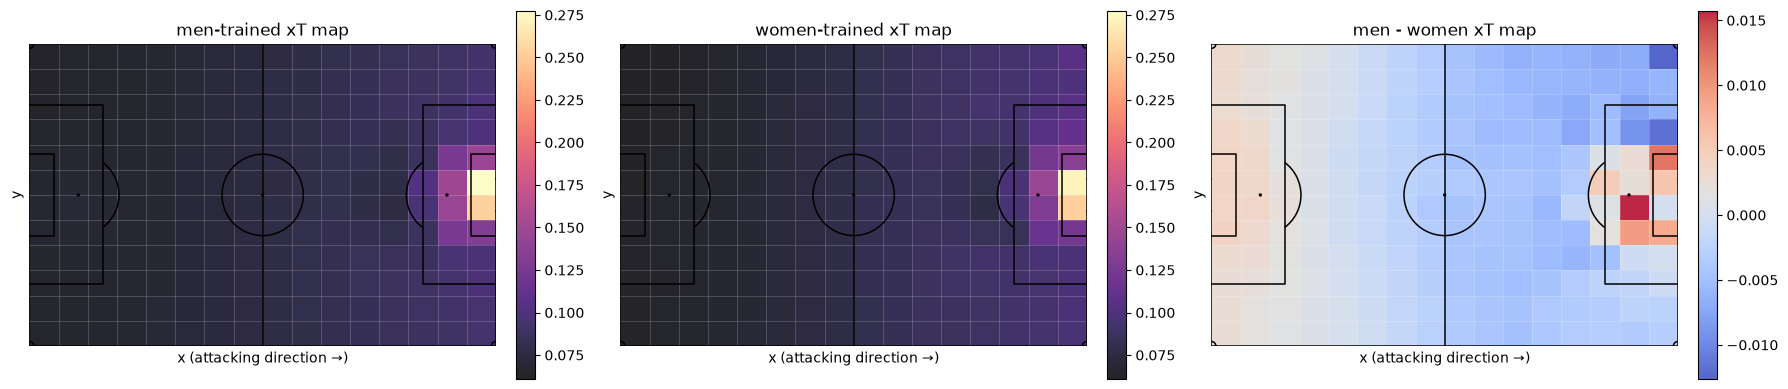

In [14]:
def plot_xt_map(xt_map, title, ax=None, cmap="magma", vmin=None, vmax=None):
    '''Plot one xT map on a 105x68 football pitch.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.8))

    pitch = Pitch(
        pitch_type="custom",
        pitch_length=PITCH_LENGTH,
        pitch_width=PITCH_WIDTH,
        pitch_color="white",
        line_color="black",
        linewidth=1.1,
        line_zorder=3,
        goal_type="box",
        corner_arcs=True,
    )
    pitch.draw(ax=ax)

    heatmap = ax.imshow(
        xt_map,
        origin="lower",
        extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH],
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=0.86,
        interpolation="nearest",
        zorder=1,
    )

    for x_value in np.linspace(0, PITCH_LENGTH, GRID_COLS + 1):
        ax.plot([x_value, x_value], [0, PITCH_WIDTH], color="white", alpha=0.28, linewidth=0.45, zorder=2)
    for y_value in np.linspace(0, PITCH_WIDTH, GRID_ROWS + 1):
        ax.plot([0, PITCH_LENGTH], [y_value, y_value], color="white", alpha=0.28, linewidth=0.45, zorder=2)

    ax.set_title(title)
    ax.set_xlabel("x (attacking direction →)")
    ax.set_ylabel("y")
    ax.set_xlim(0, PITCH_LENGTH)
    ax.set_ylim(0, PITCH_WIDTH)
    ax.set_aspect("equal", adjustable="box")
    plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    return ax

shared_vmin = min(men_xt_map.min(), women_xt_map.min())
shared_vmax = max(men_xt_map.max(), women_xt_map.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_xt_map(men_xt_map, "men-trained xT map", axes[0], vmin=shared_vmin, vmax=shared_vmax)
plot_xt_map(women_xt_map, "women-trained xT map", axes[1], vmin=shared_vmin, vmax=shared_vmax)
plot_xt_map(men_xt_map - women_xt_map, "men - women xT map", axes[2], cmap="coolwarm")
plt.tight_layout()
plt.show()

## 15. 可视化球员层面差异

如果点都贴近对角线，说明两个 xT map 对同一批女足球员的排序很接近。如果有明显偏离，就说明男足训练出的 xT map 和女足训练出的 xT map 对某些球员/动作的估值不同。

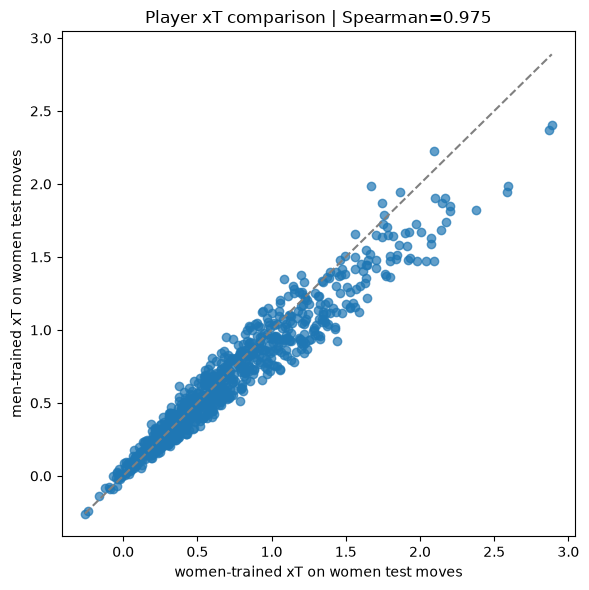

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    player_xt_comparison["women_model_xt"],
    player_xt_comparison["men_model_xt"],
    alpha=0.7,
)

axis_min = min(player_xt_comparison["women_model_xt"].min(), player_xt_comparison["men_model_xt"].min())
axis_max = max(player_xt_comparison["women_model_xt"].max(), player_xt_comparison["men_model_xt"].max())
ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", color="gray")

ax.set_xlabel("women-trained xT on women test moves")
ax.set_ylabel("men-trained xT on women test moves")
ax.set_title(f"Player xT comparison | Spearman={rho_xt:.3f}")
plt.tight_layout()
plt.show()

## 16. 如何解释这个结果

这个 notebook 的输出不要解释成“xT 已经完整衡量了真实足球威胁”。经典 xT 是一个 position-only model，它主要学习：平均意义上，球在球场哪些位置更危险。

因此：

- 如果 `men_model_xt` 和 `women_model_xt` 很接近，说明这版 position-based xT 没有发现明显差异。
- 但这不等于男女足在战术、球员能力、防守压力、球队风格上没有差异。
- 更谨慎的表述是：**只用位置坐标构造的 xT map，在男女足训练数据之间学到的空间威胁结构很接近/不接近。**

这也是为什么它要和 xG、VAEP 放在一起比较：xG 更关注射门，xT 更关注位置推进，VAEP 才会引入更多动作上下文。